<a href="https://colab.research.google.com/github/briskicedteaa/SP-Model-Repo/blob/main/Prototype_v0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Temporal-Difference Learning (TD Learning)**

TD learning is a method where a system updates what it expects based on the difference between what it expected and what actually happened.

For this notebook, I'll be utilizing ["Tutorial 1: Learning to Predict"](https://compneuro.neuromatch.io/tutorials/W3D4_ReinforcementLearning/student/W3D4_Tutorial1.html$0) By NeuroMatch Academy.

In [ ]:

# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()


feedback_prefix = "W3D4_T1"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.8 MB/s eta 0:00:00


In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [ ]:
# @title Plotting Functions
from matplotlib import ticker

def plot_value_function(V, ax=None, show=True):
  """Plot V(s), the value function"""
  if not ax:
    fig, ax = plt.subplots()

  ax.stem(V)
  ax.set_ylabel('Value')
  ax.set_xlabel('State')
  ax.set_title("Value function: $V(s)$")

  if show:
    plt.show()


def plot_tde_trace(TDE, ax=None, show=True, skip=400):
  """Plot the TD Error across trials"""
  if not ax:
    fig, ax = plt.subplots()

  index = np.arange(0, TDE.shape[1], skip)
  im = ax.imshow(TDE[:,index])
  positions = ax.get_xticks()
  # Avoid warning when setting string tick labels
  ax.xaxis.set_major_locator(ticker.FixedLocator(positions))
  ax.set_xticklabels([f"{int(skip * x)}" for x in positions])
  ax.set_title('TD-error over learning')
  ax.set_ylabel('State')
  ax.set_xlabel('Iterations')
  ax.figure.colorbar(im)
  if show:
    plt.show()


def learning_summary_plot(V, TDE):
  """Summary plot for Ex1"""
  fig, (ax1, ax2) = plt.subplots(nrows = 2, gridspec_kw={'height_ratios': [1, 2]})

  plot_value_function(V, ax=ax1, show=False)
  plot_tde_trace(TDE, ax=ax2, show=False)
  plt.tight_layout()
  plt.show()

In [ ]:
# @title Helper Functions and Classes

def reward_guesser_title_hint(r1, r2):
  """"Provide a mildly obfuscated hint for a demo."""
  if (r1==14 and r2==6) or (r1==6 and r2==14):
    return "Technically correct...(the best kind of correct)"

  if  ~(~(r1+r2) ^ 11) - 1 == (6 | 24): # Don't spoil the fun :-)
    return "Congratulations! You solved it!"

  return "Keep trying...."


class ClassicalConditioning:

    def __init__(self, n_steps, reward_magnitude, reward_time):

        # Task variables
        self.n_steps = n_steps
        self.n_actions = 0
        self.cs_time = int(n_steps/4) - 1

        # Reward variables
        self.reward_state = [0,0]
        self.reward_magnitude = None
        self.reward_probability = None
        self.reward_time = None

        # Time step at which the conditioned stimulus is presented
        self.set_reward(reward_magnitude, reward_time)

        # Create a state dictionary
        self._create_state_dictionary()

    def set_reward(self, reward_magnitude, reward_time):

        """
        Determine reward state and magnitude of reward
        """
        if reward_time >= self.n_steps - self.cs_time:
            self.reward_magnitude = 0

        else:
            self.reward_magnitude = reward_magnitude
            self.reward_state = [1, reward_time]

    def get_outcome(self, current_state):

        """
        Determine next state and reward
        """
        # Update state
        if current_state < self.n_steps - 1:
            next_state = current_state + 1
        else:
            next_state = 0

        # Check for reward
        if self.reward_state == self.state_dict[current_state]:
            reward = self.reward_magnitude
        else:
            reward = 0

        return next_state, reward

    def _create_state_dictionary(self):

        """
        This dictionary maps number of time steps/ state identities
        in each episode to some useful state attributes:

        state      - 0 1 2 3 4 5 (cs) 6 7 8 9 10 11 12 ...
        is_delay   - 0 0 0 0 0 0 (cs) 1 1 1 1  1  1  1 ...
        t_in_delay - 0 0 0 0 0 0 (cs) 1 2 3 4  5  6  7 ...
        """
        d = 0

        self.state_dict = {}
        for s in range(self.n_steps):
            if s <= self.cs_time:
                self.state_dict[s] = [0,0]
            else:
                d += 1 # Time in delay
                self.state_dict[s] = [1,d]


class MultiRewardCC(ClassicalConditioning):
  """Classical conditioning paradigm, except that one randomly selected reward,
    magnitude, from a list, is delivered of a single fixed reward."""
  def __init__(self, n_steps, reward_magnitudes, reward_time=None):
    """"Build a multi-reward classical conditioning environment
      Args:
        - nsteps: Maximum number of steps
        - reward_magnitudes: LIST of possible reward magnitudes.
        - reward_time: Single fixed reward time
      Uses numpy global random state.
      """
    super().__init__(n_steps, 1, reward_time)
    self.reward_magnitudes = reward_magnitudes

  def get_outcome(self, current_state):
    next_state, reward = super().get_outcome(current_state)
    if reward:
      reward=np.random.choice(self.reward_magnitudes)
    return next_state, reward


class ProbabilisticCC(ClassicalConditioning):
  """Classical conditioning paradigm, except that rewards are stochastically omitted."""
  def __init__(self, n_steps, reward_magnitude, reward_time=None, p_reward=0.75):
    """"Build a multi-reward classical conditioning environment
      Args:
        - nsteps: Maximum number of steps
        - reward_magnitudes: Reward magnitudes.
        - reward_time: Single fixed reward time.
        - p_reward: probability that reward is actually delivered in rewarding state
      Uses numpy global random state.
      """
    super().__init__(n_steps, reward_magnitude, reward_time)
    self.p_reward = p_reward

  def get_outcome(self, current_state):
    next_state, reward = super().get_outcome(current_state)
    if reward:
      reward*= int(np.random.uniform(size=1)[0] < self.p_reward)
    return next_state, reward

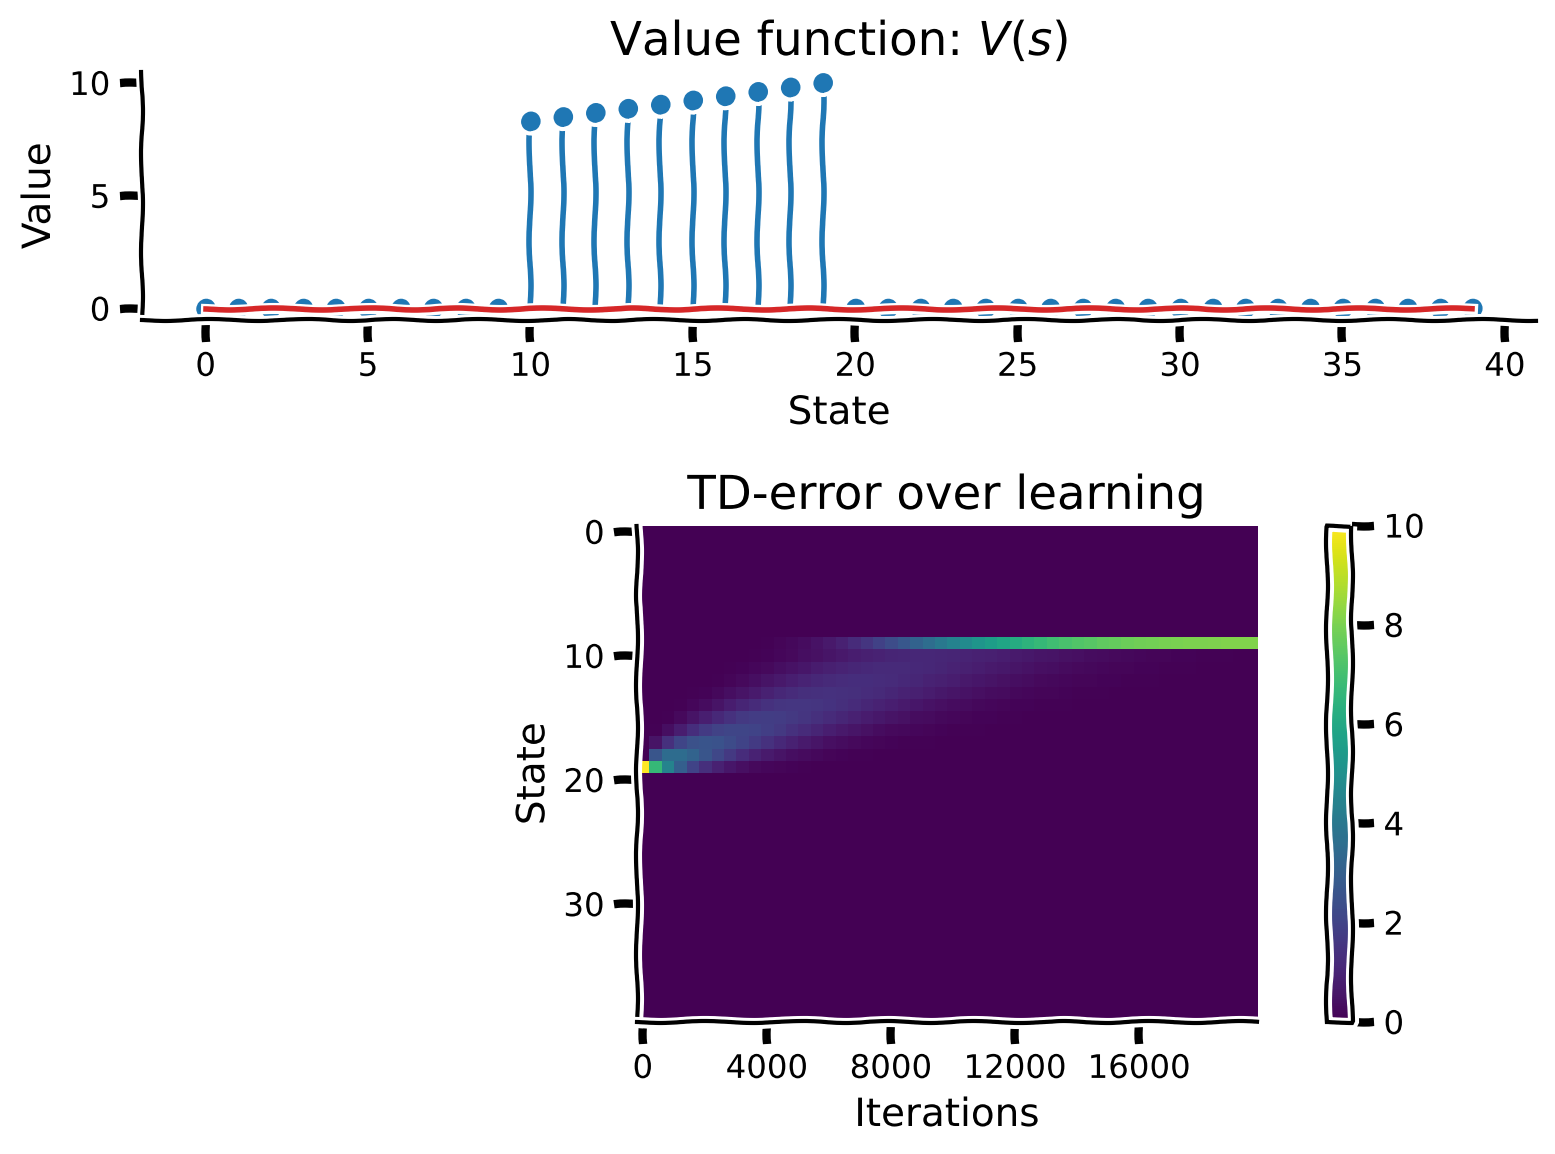

In [ ]:
def td_learner(env, n_trials, gamma=0.98, alpha=0.001):
  """ Temporal Difference learning

  Args:
    env (object): the environment to be learned
    n_trials (int): the number of trials to run
    gamma (float): temporal discount factor
    alpha (float): learning rate

  Returns:
    ndarray, ndarray: the value function and temporal difference error arrays
  """
  V = np.zeros(env.n_steps) # Array to store values over states (time)
  TDE = np.zeros((env.n_steps, n_trials)) # Array to store TD errors

  for n in range(n_trials):

    state = 0 # Initial state
    for t in range(env.n_steps):

      # Get next state and next reward
      next_state, reward = env.get_outcome(state)

      # Is the current state in the delay period (after CS)?
      is_delay = env.state_dict[state][0]

      # Write an expression to compute the TD-error
      TDE[state, n] = (reward + gamma * V[next_state] - V[state])

      # Write an expression to update the value function
      V[state] += alpha * TDE[state, n] * is_delay

      # Update state
      state = next_state

  return V, TDE


# Initialize classical conditioning class
env = ClassicalConditioning(n_steps=40, reward_magnitude=10, reward_time=10)

# Perform temporal difference learning
V, TDE = td_learner(env, n_trials=20000)

# Visualize
with plt.xkcd():
  learning_summary_plot(V, TDE)

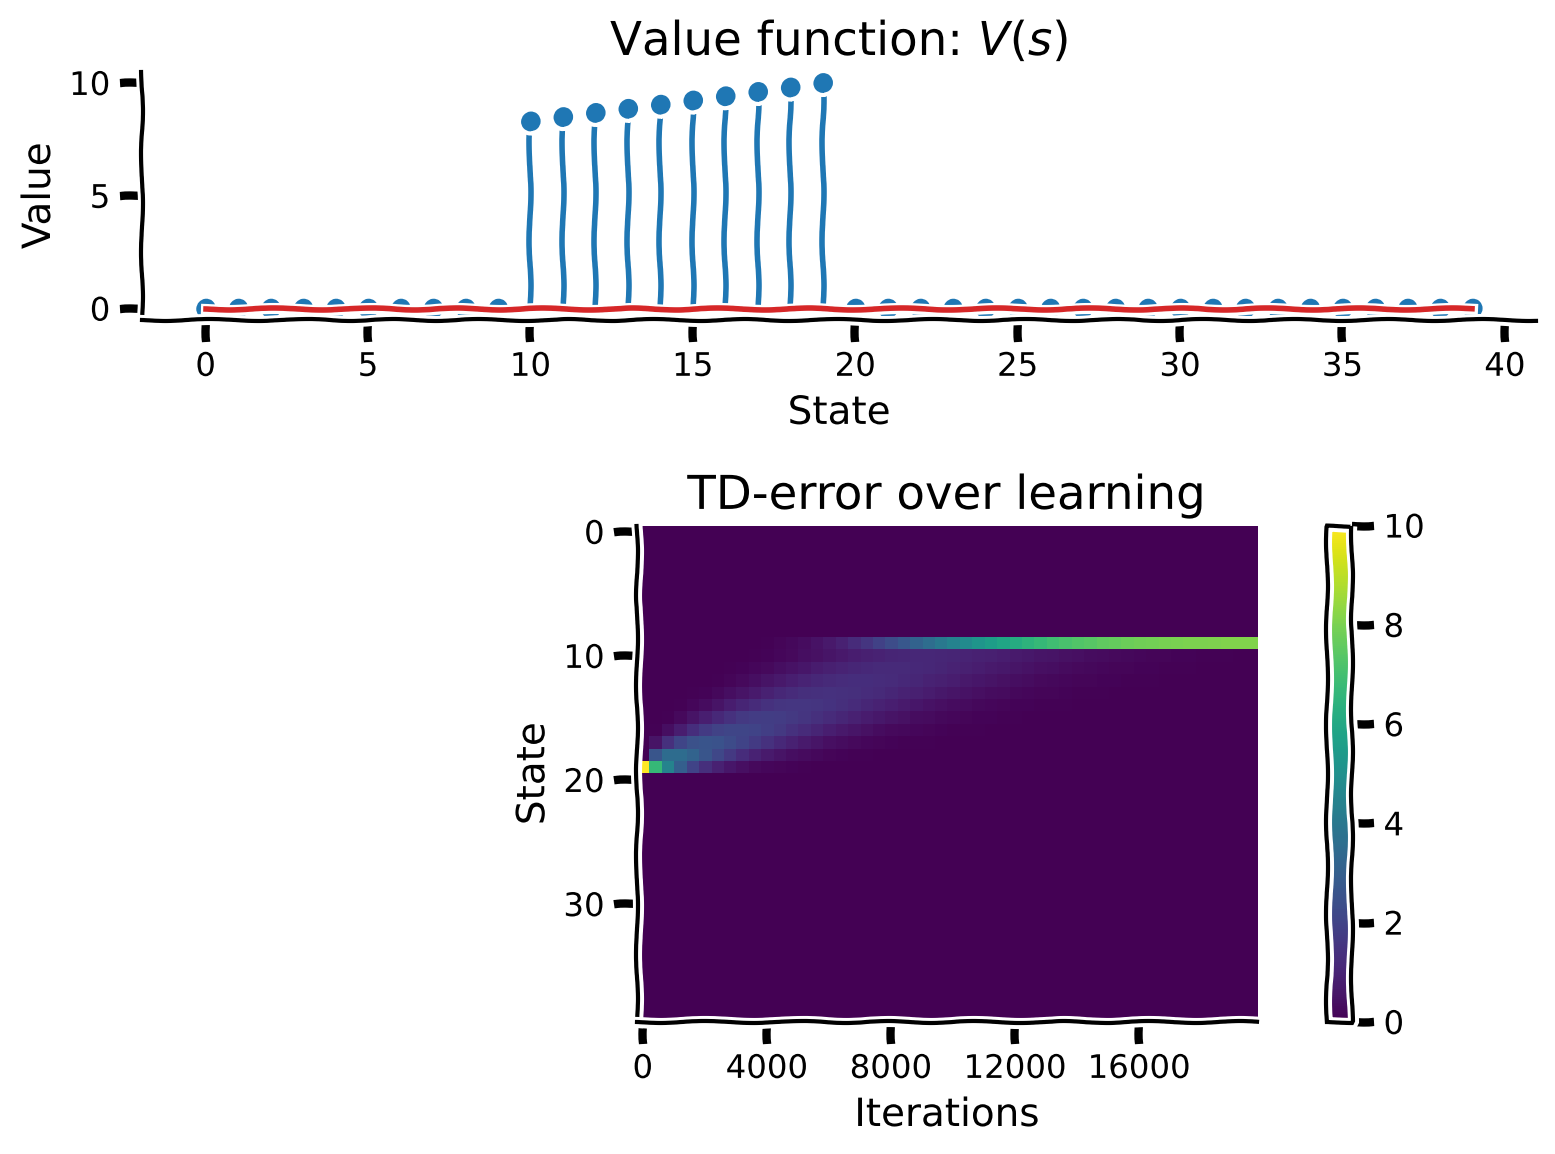

In [ ]:
def td_learner_history(env, n_trials, gamma=0.98, alpha=0.001):
  """ Temporal Difference learning

  Args
    env (object): the environment to be learned
    n_trials (int): the number of trials to run
    gamma (float): temporal discount factor
    alpha (float): learning rate

  Returns:
    ndarray, ndarray: the value function and temporal difference error arrays
  """
  V = np.zeros(env.n_steps) # Array to store values over states (time)
  TDE = np.zeros((env.n_steps, n_trials)) # Array to store TD errors

  tracked_state = 15

  value_history = np.zeros(n_trials)

  for n in range(n_trials):

    state = 0 # Initial state
    for t in range(env.n_steps):

      # Get next state and next reward
      next_state, reward = env.get_outcome(state)

      # Is the current state in the delay period (after CS)?
      is_delay = env.state_dict[state][0]

      # Write an expression to compute the TD-error
      TDE[state, n] = (reward + gamma * V[next_state] - V[state])

      # Write an expression to update the value function
      V[state] += alpha * TDE[state, n] * is_delay

      # Update state
      state = next_state

    value_history[n] = V[tracked_state]

  return V, TDE, value_history

# Initialize classical conditioning class
env = ClassicalConditioning(n_steps=40, reward_magnitude=10, reward_time=10)

# Perform temporal difference learning
V, TDE, value_history = td_learner_history(env, n_trials=20000)

# Visualize
with plt.xkcd():
  learning_summary_plot(V, TDE)

In [ ]:
#@markdown The learned TD value was normalized to a 0–1 range and rescaled to a maximum Wilson-Cowan external excitatory input of 0.3. This transformation serves only as a prototype interface between the learning and dynamical components and is not intended as a biological equivalence.

env = ClassicalConditioning(
    n_steps=40,
    reward_magnitude=10,
    reward_time=10
)

V, TDE, value_history = td_learner_history(

    env,

    n_trials=20000

)

learned_signal = value_history / value_history.max()

max_input = 0.30

input_history = learned_signal * max_input

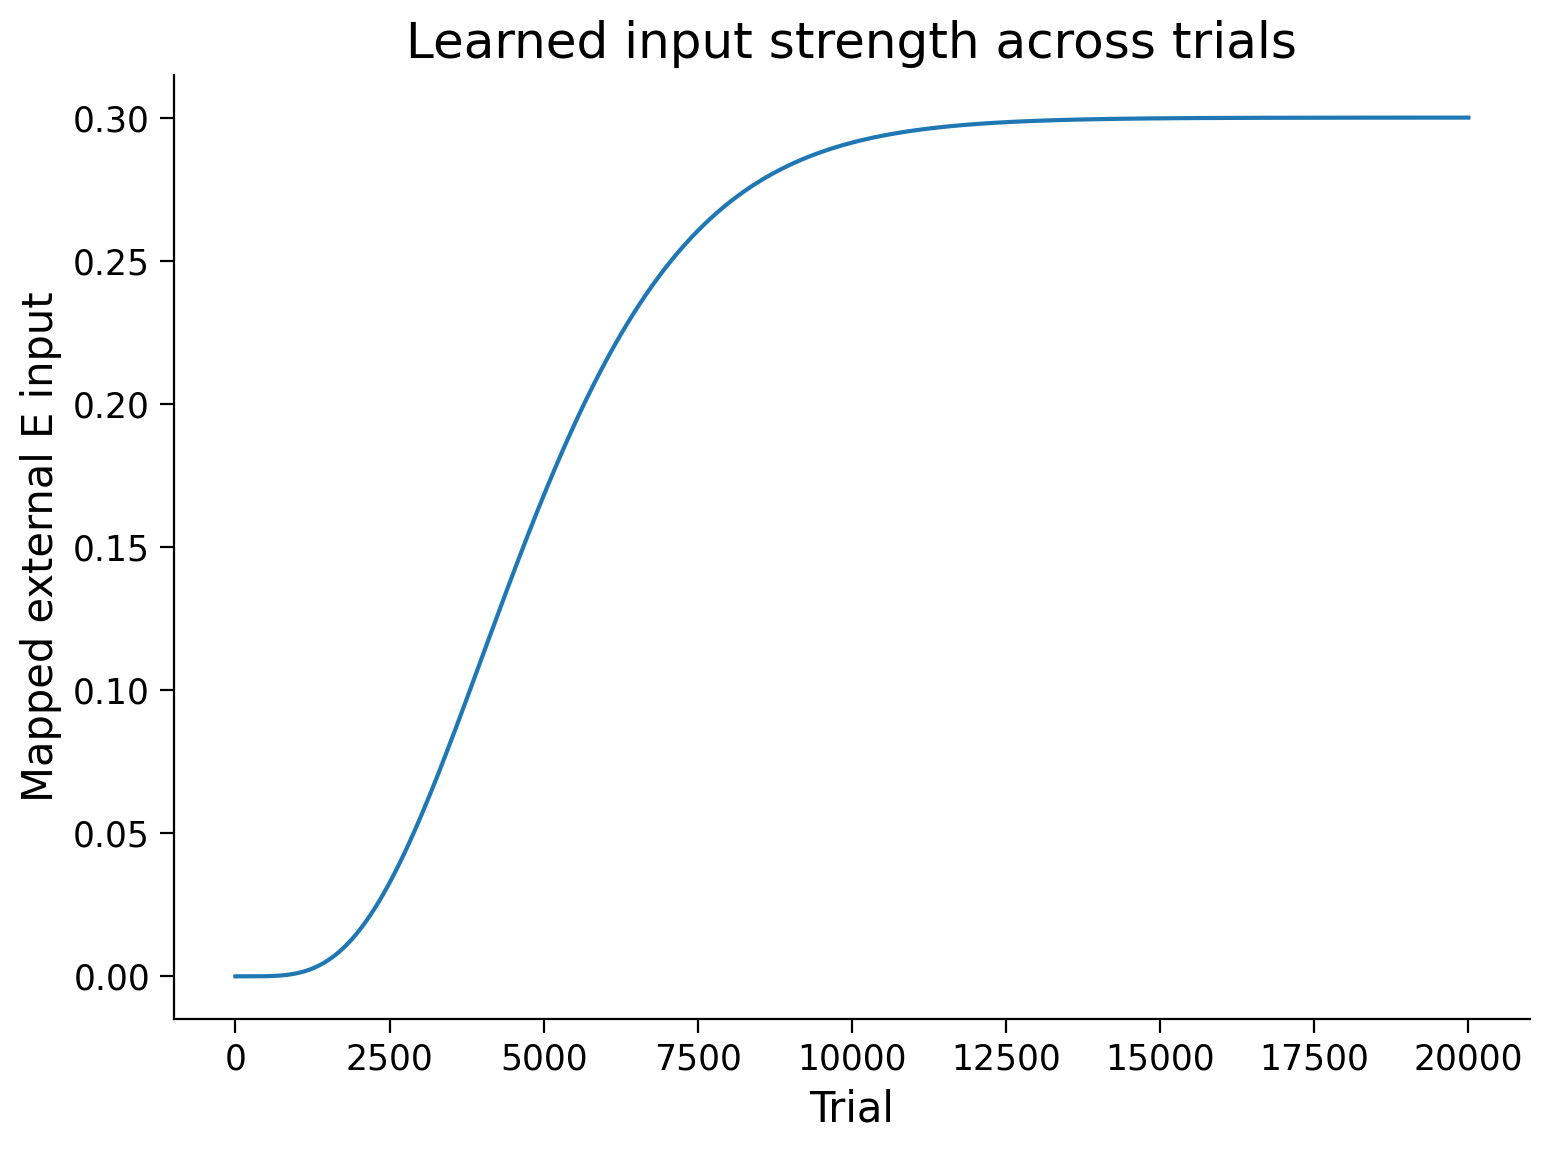

In [ ]:
plt.plot(input_history)
plt.xlabel("Trial")
plt.ylabel("Mapped external E input")
plt.title("Learned input strength across trials")
plt.show()

In [ ]:
early_trial = 100
middle_trial = 5000
late_trial = 19000

early_input = input_history[early_trial]
middle_input = input_history[middle_trial]
late_input = input_history[late_trial]

print("Early input:", early_input)
print("Middle input:", middle_input)
print("Late input:", late_input)

Early input: 2.1937302332007177e-08
Middle input: 0.1679338322624526
Late input: 0.29999374228058723


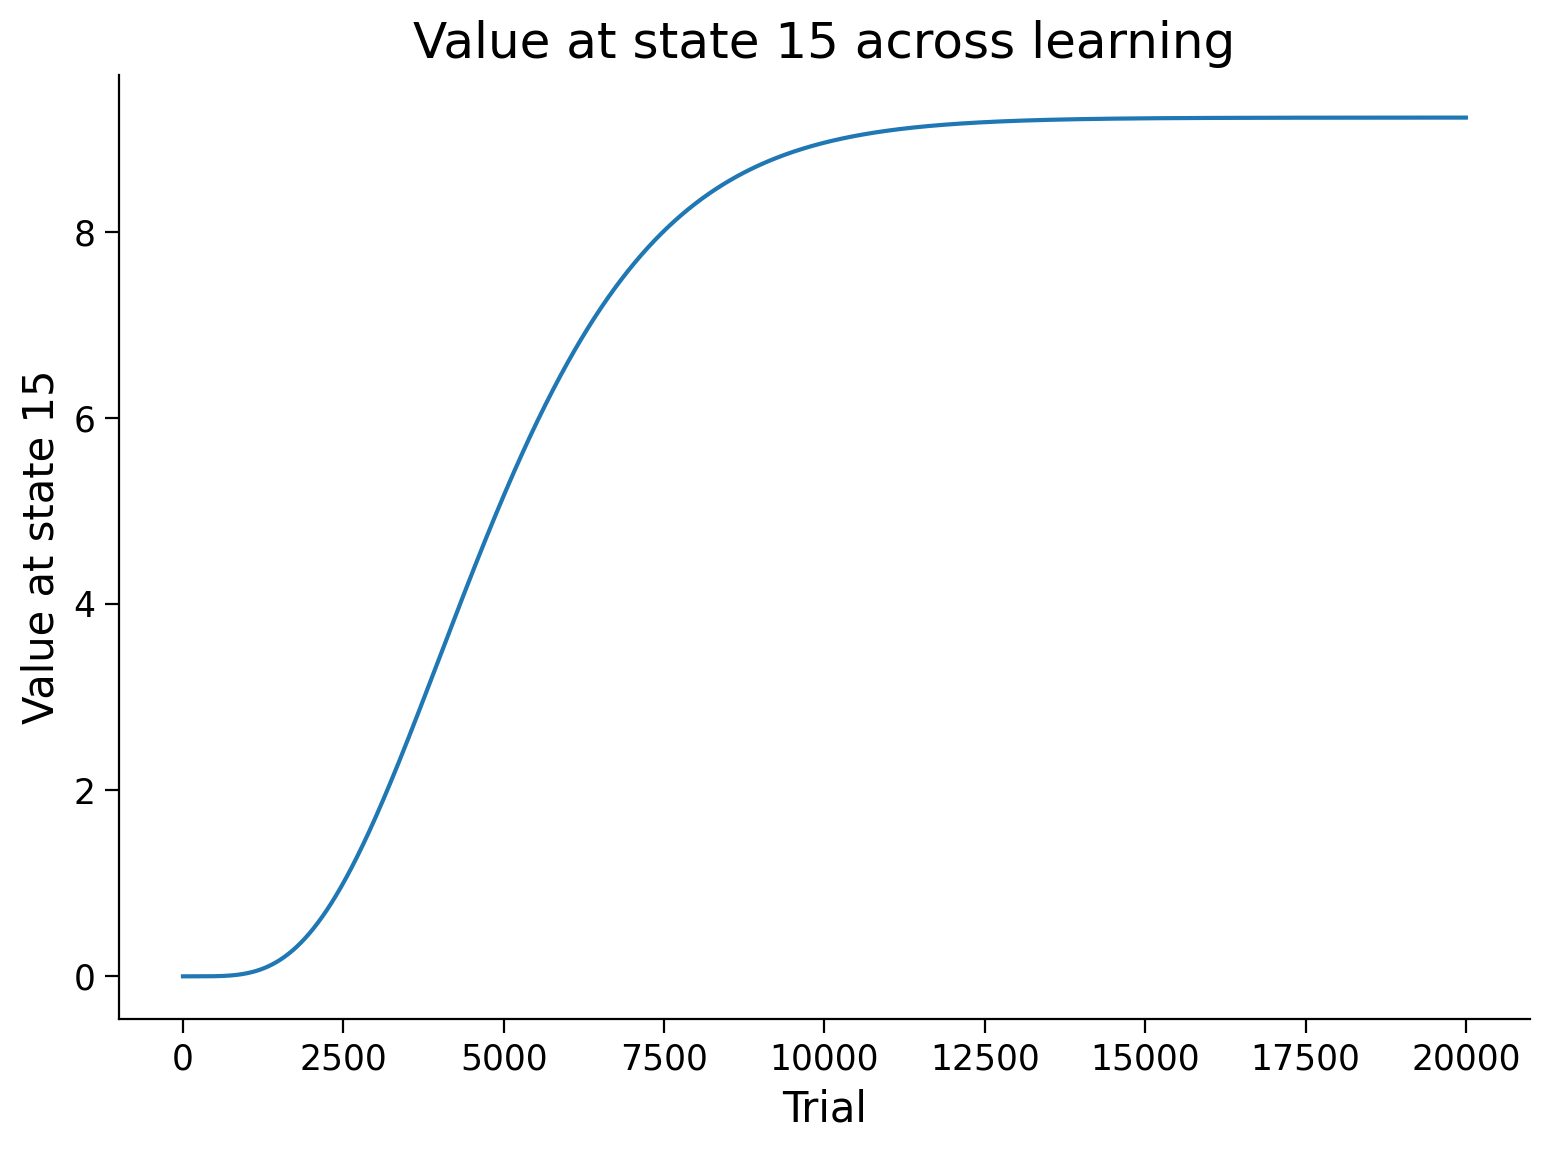

In [ ]:
plt.plot(value_history)
plt.xlabel("Trial")
plt.ylabel("Value at state 15")
plt.title("Value at state 15 across learning")
plt.show()

#### **Connecting learning to Wilson-Cowan**

In my last notebook, I experimented around with the Wilson-Cowan Model. Now, I'm going to attempt to integrate it with TD Learning.

In [ ]:
#@markdown Implementing Plotting Functions for Wilson-Cowan Workflow In Previous Notebook

def plot_FI_inverse(x, a, theta):
  f, ax = plt.subplots()
  ax.plot(x, F_inv(x, a=a, theta=theta))
  ax.set(xlabel="", ylabel="")


def plot_FI_EI(x, FI_exc, FI_inh):
  plt.figure()
  plt.plot(x, FI_exc, 'b', label='E population')
  plt.plot(x, FI_inh, 'r', label='I population')
  plt.legend(loc='lower right')
  plt.xlabel('x (a.u.)')
  plt.ylabel('F(x)')
  plt.show()


def my_test_plot(t, rE1, rI1, rE2, rI2):

  plt.figure()
  ax1 = plt.subplot(211)
  ax1.plot(pars['range_t'], rE1, 'b', label='E population')
  ax1.plot(pars['range_t'], rI1, 'r', label='I population')
  ax1.set_ylabel('Activity')
  ax1.legend(loc='best')

  ax2 = plt.subplot(212, sharex=ax1, sharey=ax1)
  ax2.plot(pars['range_t'], rE2, 'b', label='E population')
  ax2.plot(pars['range_t'], rI2, 'r', label='I population')
  ax2.set_xlabel('t (ms)')
  ax2.set_ylabel('Activity')
  ax2.legend(loc='best')

  plt.tight_layout()
  plt.show()


def plot_nullclines(Exc_null_rE, Exc_null_rI, Inh_null_rE, Inh_null_rI):

  plt.figure()
  plt.plot(Exc_null_rE, Exc_null_rI, 'b', label='E nullcline')
  plt.plot(Inh_null_rE, Inh_null_rI, 'r', label='I nullcline')
  plt.xlabel(r'')
  plt.ylabel(r'')
  plt.legend(loc='best')
  plt.show()


def my_plot_nullcline(pars):
  Exc_null_rE = np.linspace(-0.01, 0.96, 100)
  Exc_null_rI = get_E_nullcline(Exc_null_rE, **pars)
  Inh_null_rI = np.linspace(-.01, 0.8, 100)
  Inh_null_rE = get_I_nullcline(Inh_null_rI, **pars)

  plt.plot(Exc_null_rE, Exc_null_rI, 'b', label='E nullcline')
  plt.plot(Inh_null_rE, Inh_null_rI, 'r', label='I nullcline')
  plt.xlabel(r'')
  plt.ylabel(r'')
  plt.legend(loc='best')


def my_plot_vector(pars, my_n_skip=2, myscale=5):
  EI_grid = np.linspace(0., 1., 20)
  rE, rI = np.meshgrid(EI_grid, EI_grid)
  drEdt, drIdt = EIderivs(rE, rI, **pars)

  n_skip = my_n_skip

  plt.quiver(rE[::n_skip, ::n_skip], rI[::n_skip, ::n_skip],
             drEdt[::n_skip, ::n_skip], drIdt[::n_skip, ::n_skip],
             angles='xy', scale_units='xy', scale=myscale, facecolor='c')

  plt.xlabel(r'')
  plt.ylabel(r'')


def my_plot_trajectory(pars, mycolor, x_init, mylabel):
  pars = pars.copy()
  pars['rE_init'], pars['rI_init'] = x_init[0], x_init[1]
  rE_tj, rI_tj = simulate_wc(**pars)

  plt.plot(rE_tj, rI_tj, color=mycolor, label=mylabel)
  plt.plot(x_init[0], x_init[1], 'o', color=mycolor, ms=8)
  plt.xlabel(r'')
  plt.ylabel(r'')


def my_plot_trajectories(pars, dx, n, mylabel):
  """
  Solve for I along the E_grid from dE/dt = 0.

  Expects:
  pars    : Parameter dictionary
  dx      : increment of initial values
  n       : n*n trjectories
  mylabel : label for legend

  Returns:
    figure of trajectory
  """
  pars = pars.copy()
  for ie in range(n):
    for ii in range(n):
      pars['rE_init'], pars['rI_init'] = dx * ie, dx * ii
      rE_tj, rI_tj = simulate_wc(**pars)
      if (ie == n-1) & (ii == n-1):
          plt.plot(rE_tj, rI_tj, 'gray', alpha=0.8, label=mylabel)
      else:
          plt.plot(rE_tj, rI_tj, 'gray', alpha=0.8)

  plt.xlabel(r'')
  plt.ylabel(r'')


def plot_complete_analysis(pars):
  plt.figure(figsize=(7.7, 6.))

  # plot example trajectories
  my_plot_trajectories(pars, 0.2, 6,
                       'Sample trajectories \nfor different init. conditions')
  my_plot_trajectory(pars, 'orange', [0.6, 0.8],
                     'Sample trajectory for \nlow activity')
  my_plot_trajectory(pars, 'm', [0.6, 0.6],
                     'Sample trajectory for \nhigh activity')

  # plot nullclines
  my_plot_nullcline(pars)

  # plot vector field
  EI_grid = np.linspace(0., 1., 20)
  rE, rI = np.meshgrid(EI_grid, EI_grid)
  drEdt, drIdt = EIderivs(rE, rI, **pars)
  n_skip = 2
  plt.quiver(rE[::n_skip, ::n_skip], rI[::n_skip, ::n_skip],
             drEdt[::n_skip, ::n_skip], drIdt[::n_skip, ::n_skip],
             angles='xy', scale_units='xy', scale=5., facecolor='c')

  plt.legend(loc=[1.02, 0.57], handlelength=1)
  plt.show()


def plot_fp(x_fp, position=(0.02, 0.1), rotation=0):
  plt.plot(x_fp[0], x_fp[1], 'ko', ms=8)
  plt.text(x_fp[0] + position[0], x_fp[1] + position[1],
           f'Fixed Point1=\n({x_fp[0]:.3f}, {x_fp[1]:.3f})',
           horizontalalignment='center', verticalalignment='bottom',
           rotation=rotation)

In [ ]:
#@markdown Implementing Helper Functions

def default_pars(**kwargs):
  pars = {}

  # Excitatory parameters
  pars['tau_E'] = 1.     # Timescale of the E population [ms]
  pars['a_E'] = 1.2      # Gain of the E population
  pars['theta_E'] = 2.8  # Threshold of the E population

  # Inhibitory parameters
  pars['tau_I'] = 2.0    # Timescale of the I population [ms]
  pars['a_I'] = 1.0      # Gain of the I population
  pars['theta_I'] = 4.0  # Threshold of the I population

  # Connection strength
  pars['wEE'] = 9.   # E to E
  pars['wEI'] = 4.   # I to E
  pars['wIE'] = 13.  # E to I
  pars['wII'] = 11.  # I to I

  # External input
  pars['I_ext_E'] = 0.
  pars['I_ext_I'] = 0.

  # simulation parameters
  pars['T'] = 50.        # Total duration of simulation [ms]
  pars['dt'] = .1        # Simulation time step [ms]
  pars['rE_init'] = 0.2  # Initial value of E
  pars['rI_init'] = 0.2  # Initial value of I

  # External parameters if any
  for k in kwargs:
      pars[k] = kwargs[k]

  # Vector of discretized time points [ms]
  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])

  return pars


def F(x, a, theta):
  """
  Population activation function, F-I curve

  Args:
    x     : the population input
    a     : the gain of the function
    theta : the threshold of the function

  Returns:
    f     : the population activation response f(x) for input x
  """

  # add the expression of f = F(x)
  f = (1 + np.exp(-a * (x - theta)))**-1 - (1 + np.exp(a * theta))**-1

  return f


def dF(x, a, theta):
  """
  Derivative of the population activation function.

  Args:
    x     : the population input
    a     : the gain of the function
    theta : the threshold of the function

  Returns:
    dFdx  :  Derivative of the population activation function.
  """

  dFdx = a * np.exp(-a * (x - theta)) * (1 + np.exp(-a * (x - theta)))**-2

  return dFdx

#### This step integrates the temporal-difference learning model with the Wilson-Cowan model. Learned values from different stages of TD learning (early, middle, and late) were mapped onto the strength of an external excitatory input (I_ext_E) applied to the Wilson-Cowan model. The pulse timing and Wilson-Cowan parameters were kept the same between conditions so that the effect of changing the learned input could be compared.

In [ ]:
def simulate_wc_pulse(tau_E, a_E, theta_E, tau_I, a_I, theta_I,
                wEE, wEI, wIE, wII, I_ext_E, I_ext_I,
                rE_init, rI_init, dt, range_t, pulse_start, pulse_end, **other_pars):
  """
  Simulate the Wilson-Cowan equations

  Args:
    Parameters of the Wilson-Cowan model

  Returns:
    rE, rI (arrays) : Activity of excitatory and inhibitory populations
  """
  # Initialize activity arrays
  Lt = range_t.size
  rE = np.append(rE_init, np.zeros(Lt - 1))
  rI = np.append(rI_init, np.zeros(Lt - 1))

  I_ext_E_array = np.zeros(Lt)
  pulse_mask = (range_t >= pulse_start) & (range_t < pulse_end)
  I_ext_E_array[pulse_mask] = I_ext_E

  I_ext_I = I_ext_I * np.ones(Lt)

  # Simulate the Wilson-Cowan equations
  for k in range(Lt - 1):

    # Calculate the derivative of the E population
    drE = dt / tau_E * (-rE[k] + F(wEE * rE[k] - wEI * rI[k] + I_ext_E_array[k],
                                   a_E, theta_E))

    # Calculate the derivative of the I population
    drI = dt / tau_I * (-rI[k] + F(wIE * rE[k] - wII * rI[k] + I_ext_I[k],
                                   a_I, theta_I))

    # Update using Euler's method
    rE[k + 1] = rE[k] + drE
    rI[k + 1] = rI[k] + drI

  return rE, rI, I_ext_E_array


pars = default_pars(
    rE_init=0.30,
    rI_init=0.15,
    I_ext_E=0.30,
    pulse_start=5
)

pars_early = default_pars(
    rE_init=0.30,
    rI_init=0.15,
    I_ext_E=early_input
)

pulse_start  = 5
pulse_end = 25

pars_early["pulse_start"] = pulse_start
pars_early["pulse_end"] = pulse_end

rE_early, rI_early, pulse_early = simulate_wc_pulse(**pars_early)

In [ ]:
def simulate_wc_pulse(tau_E, a_E, theta_E, tau_I, a_I, theta_I,
                wEE, wEI, wIE, wII, I_ext_E, I_ext_I,
                rE_init, rI_init, dt, range_t, pulse_start, pulse_end, **other_pars):
  """
  Simulate the Wilson-Cowan equations

  Args:
    Parameters of the Wilson-Cowan model

  Returns:
    rE, rI (arrays) : Activity of excitatory and inhibitory populations
  """
  # Initialize activity arrays
  Lt = range_t.size
  rE = np.append(rE_init, np.zeros(Lt - 1))
  rI = np.append(rI_init, np.zeros(Lt - 1))

  I_ext_E_array = np.zeros(Lt)
  pulse_mask = (range_t >= pulse_start) & (range_t < pulse_end)
  I_ext_E_array[pulse_mask] = I_ext_E

  I_ext_I = I_ext_I * np.ones(Lt)

  # Simulate the Wilson-Cowan equations
  for k in range(Lt - 1):

    # Calculate the derivative of the E population
    drE = dt / tau_E * (-rE[k] + F(wEE * rE[k] - wEI * rI[k] + I_ext_E_array[k],
                                   a_E, theta_E))

    # Calculate the derivative of the I population
    drI = dt / tau_I * (-rI[k] + F(wIE * rE[k] - wII * rI[k] + I_ext_I[k],
                                   a_I, theta_I))

    # Update using Euler's method
    rE[k + 1] = rE[k] + drE
    rI[k + 1] = rI[k] + drI

  return rE, rI, I_ext_E_array


pars = default_pars(
    rE_init=0.30,
    rI_init=0.15,
    I_ext_E=0.30,
    pulse_start=5
)

pars_middle = default_pars(
    rE_init=0.30,
    rI_init=0.15,
    I_ext_E=middle_input
)

pars_middle["pulse_start"] = pulse_start
pars_middle["pulse_end"] = pulse_end

rE_middle, rI_middle, pulse_middle = simulate_wc_pulse(**pars_middle)

In [ ]:
def simulate_wc_pulse(tau_E, a_E, theta_E, tau_I, a_I, theta_I,
                wEE, wEI, wIE, wII, I_ext_E, I_ext_I,
                rE_init, rI_init, dt, range_t, pulse_start, pulse_end, **other_pars):
  """
  Simulate the Wilson-Cowan equations

  Args:
    Parameters of the Wilson-Cowan model

  Returns:
    rE, rI (arrays) : Activity of excitatory and inhibitory populations
  """
  # Initialize activity arrays
  Lt = range_t.size
  rE = np.append(rE_init, np.zeros(Lt - 1))
  rI = np.append(rI_init, np.zeros(Lt - 1))

  I_ext_E_array = np.zeros(Lt)
  pulse_mask = (range_t >= pulse_start) & (range_t < pulse_end)
  I_ext_E_array[pulse_mask] = I_ext_E

  I_ext_I = I_ext_I * np.ones(Lt)

  # Simulate the Wilson-Cowan equations
  for k in range(Lt - 1):

    # Calculate the derivative of the E population
    drE = dt / tau_E * (-rE[k] + F(wEE * rE[k] - wEI * rI[k] + I_ext_E_array[k],
                                   a_E, theta_E))

    # Calculate the derivative of the I population
    drI = dt / tau_I * (-rI[k] + F(wIE * rE[k] - wII * rI[k] + I_ext_I[k],
                                   a_I, theta_I))

    # Update using Euler's method
    rE[k + 1] = rE[k] + drE
    rI[k + 1] = rI[k] + drI

  return rE, rI, I_ext_E_array


pars = default_pars(
    rE_init=0.30,
    rI_init=0.15,
    I_ext_E=0.30,
    pulse_start=5
)

pars_late = default_pars(
    rE_init=0.30,
    rI_init=0.15,
    I_ext_E=late_input
)

pars_late["pulse_start"] = pulse_start
pars_late["pulse_end"] = pulse_end

rE_late, rI_late, pulse_late = simulate_wc_pulse(**pars_late)

#### **Plot interpretation**

All three trajectories begin at the same excitatory population activity of 0.30 and initially decrease similarly. Once the external input is applied, the trajectories begin to separate. During early learning, the learned input is weak, so excitatory activity continues toward zero. During middle learning, the stronger input temporarily maintains a small amount of excitatory activity. During late learning, the strongest input maintains the highest excitatory activity while the pulse is present. After the input ends at 25 ms, all three trajectories return toward zero.

This shows that as the learned value increases across TD learning, its mapped external input produces a progressively stronger effect on the Wilson-Cowan excitatory population.

The prototype successfully connects the two models: output produced by TD learning can be converted into an input that changes Wilson-Cowan population dynamics. The Wilson-Cowan model itself is not learning. Instead, its response changes because the input it receives depends on the stage of learning.

However, the current mapping between TD value and external excitatory input is a modeling choice rather than a biologically established relationship. Therefore, this result demonstrates that the computational architecture works, but it does not yet establish a biological mechanism.

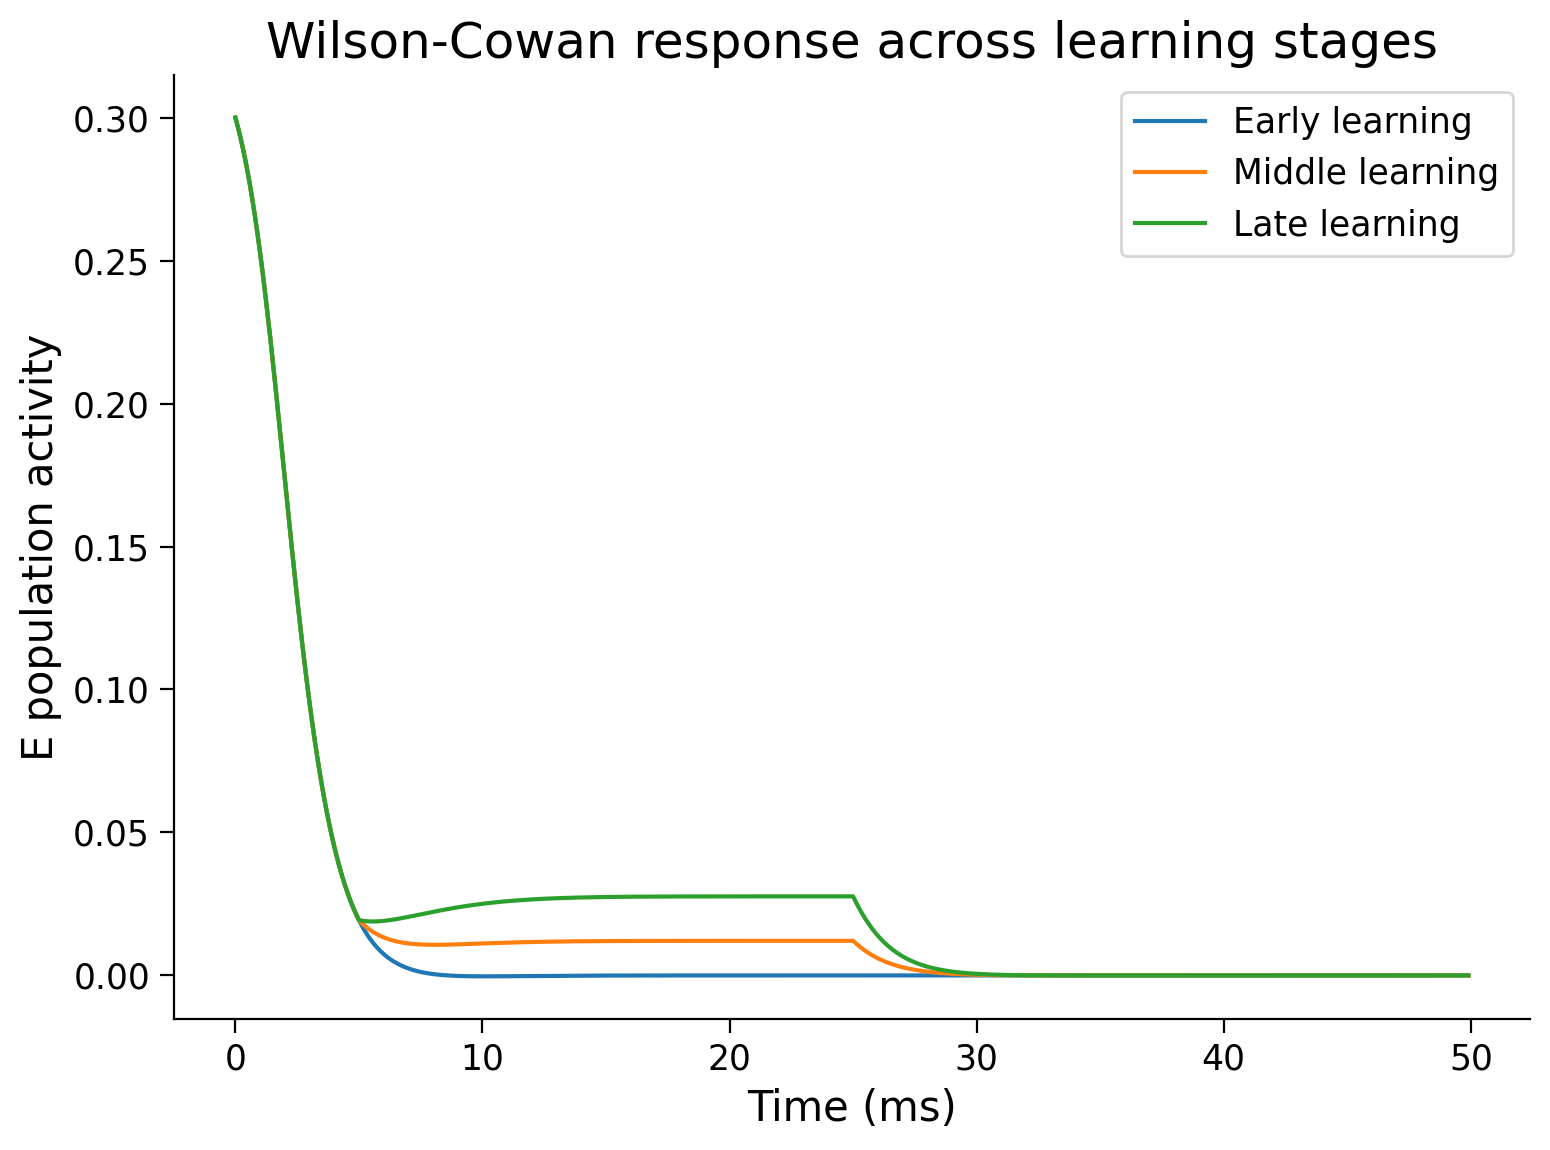

In [ ]:
plt.plot(pars_early["range_t"], rE_early, label="Early learning")
plt.plot(pars_middle["range_t"], rE_middle, label="Middle learning")
plt.plot(pars_late["range_t"], rE_late, label="Late learning")

plt.xlabel("Time (ms)")
plt.ylabel("E population activity")
plt.title("Wilson-Cowan response across learning stages")
plt.legend()
plt.show()

In [ ]:
n_snapshots = len(input_history)

rE_at_pulse_end = np.zeros(n_snapshots)

print("Number of Snapshots:", n_snapshots)
print("Storage Shape:", rE_at_pulse_end.shape)

Number of Snapshots: 20000
Storage Shape: (20000,)


In [ ]:
#@markdown value_history contains the learned value at state 15 across all 20,000 TD trials. These values were rescaled and stored in input_history, producing a corresponding external excitatory input (I_ext_E) for every TD trial. A Wilson-Cowan simulation was then run separately for each of those 20,000 inputs. The excitatory population activity (rE) at the end of the 25 ms pulse was extracted from every simulation and stored in rE_at_pulse_end.

#@markdown Earlier, only early, middle, and late learning stages were compared. Using every TD trial gives a continuous view of how the Wilson-Cowan response changes throughout the entire learning process rather than relying on three snapshots.

pulse_start = 5
pulse_end = 25

for trial in range(n_snapshots):
    current_input = input_history[trial]

    pars_snapshot = default_pars(
        rE_init=0.30,
        rI_init=0.15,
        I_ext_E=current_input
    )

    pars_snapshot["pulse_start"] = pulse_start
    pars_snapshot["pulse_end"] = pulse_end

    rE_snapshot, rI_snapshot, pulse_snapshot = simulate_wc_pulse(
        **pars_snapshot
    )

    pulse_end_index = np.argmin(
        np.abs(pars_snapshot["range_t"] - pulse_end)
    )

    rE_at_pulse_end[trial] = rE_snapshot[pulse_end_index]

In [ ]:
print("First 5:", rE_at_pulse_end[:5])

print("Middle 5:", rE_at_pulse_end[9998:10003])

print("Last 5:", rE_at_pulse_end[-5:])

print("Minimum:", rE_at_pulse_end.min())

print("Maximum:", rE_at_pulse_end.max())

First 5: [-8.03594481e-08 -8.03594481e-08 -8.03594481e-08 -8.03594481e-08
 -8.03594481e-08]
Middle 5: [0.02632435 0.02632519 0.02632603 0.02632687 0.02632771]
Last 5: [0.02764926 0.02764926 0.02764926 0.02764927 0.02764927]
Minimum: -8.035944812165707e-08
Maximum: 0.0276492658709118


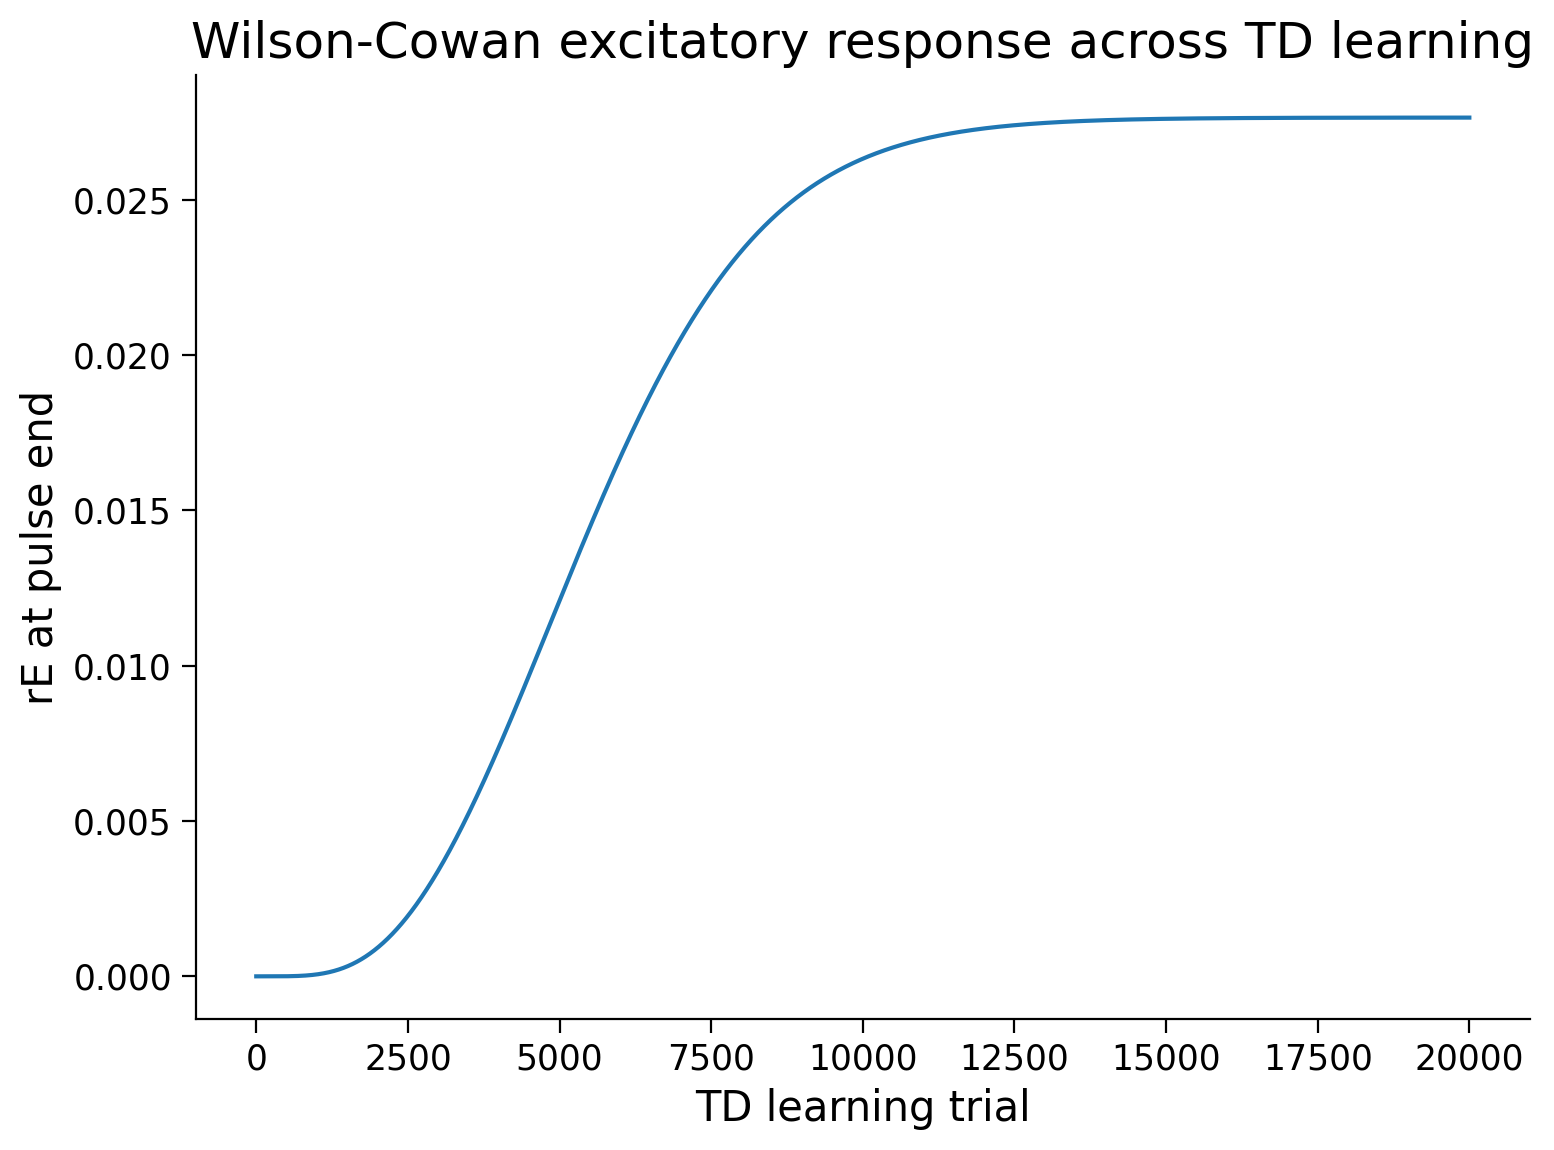

In [ ]:
#@markdown The excitatory response begins approximately at zero, increases as TD learning progresses, and eventually stabilizes around 0.02765. The shape is very similar to the TD learning curve itself. This is expected because the TD-derived signal directly controls I_ext_E, meaning that increasing TD values produce increasing external excitation in Wilson-Cowan.

#@markdown The plot looks very similar to the TD learning plots from earlier. This makes sense because the changing TD values were being used to determine I_ext_E. As the learned signal increases, the input given to Wilson-Cowan also increases.

#@markdown This does not mean that the Wilson-Cowan model itself learned. TD learning is the learning mechanism in this prototype. Wilson-Cowan is responding dynamically to an input that changes as TD learning progresses. The similarity between the two curves is therefore partly a consequence of how the models were explicitly connected.

#@markdown The inportant result from this part of the prototype is that I was able to connect the two models. Instead of running TD learing and Wilson-Cowan separately, information produced during TD learning can now influence the behavior of the Wilson-Cowan simulation.

plt.plot(rE_at_pulse_end)

plt.xlabel("TD learning trial")
plt.ylabel("rE at pulse end")
plt.title("Wilson-Cowan excitatory response across TD learning")

plt.show()

#### **Nengo Networks**

Nengo is a software platform designed to build large-scale, brain-inspired neural networks by translating high-level mathematical operations into thousands of simulating, spiking neurons. It allows researchers and engineers to model complex cognitive tasks, develop adaptive robotic control systems, and program low-power neuromorphic hardware without manually wiring individual neural connections. A key component of the platform is its library of pre-built architectures, specifically the Basal Ganglia network. This module replicates the biological brain's action-selection mechanism, functioning as a "winner-take-all" circuit that suppresses competing signals to decide which command or behavior the system should execute next.

I'll now be reffering to ["The Basal Ganglia"](https://www.nengo.ai/nengo/examples/networks/basal-ganglia.html?utm_source=chatgpt.com$0) By Nengo for this notebook.

In [ ]:
!pip install nengo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.3/542.3 kB 14.4 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import nengo

#### **Testing weaker action competition**

I decreased the dominant action input from 0.8 to 0.3 while keeping the other action inputs at 0.1. The action with the largest input stayed the same, but the difference between the dominant action and the other actions became smaller.

In [38]:
model = nengo.Network(label="Basal Ganglia")
with model:
    basal_ganglia = nengo.networks.BasalGanglia(dimensions=3)

dominant_values = [0.8, 0.6, 0.4, 0.3, 0.2, 0.15]

class ActionIterator:
    def __init__(self, dimensions, dominant_value = 0.8):
        self.actions = np.ones(dimensions) * 0.1
        self.dominant_value = dominant_value

    def step(self, t):
        dominate = int(t % 3)
        self.actions[:] = 0.1
        self.actions[dominate] = self.dominant_value
        return self.actions

action_iterator = ActionIterator(dimensions=3)

with model:
    actions = nengo.Node(action_iterator.step, label="actions")

In [ ]:
#@markdown #### **Connected The Network**

with model:
    nengo.Connection(actions, basal_ganglia.input, synapse=None)
    selected_action = nengo.Probe(basal_ganglia.output, synapse=0.01)
    input_actions = nengo.Probe(actions, synapse=0.01)

In [ ]:
#@markdown ####**Simulating the Network**

with nengo.Simulator(model) as sim:
    sim.run(6)

ERROR:nengo.cache:Decoder cache index corrupted. Reinitializing cache.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/nengo/cache.py", line 467, in __enter__
    self._load_index_file()
  File "/usr/local/lib/python3.12/dist-packages/nengo/cache.py", line 389, in _load_index_file
    with self.index_path.open("rb") as f:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/pathlib.py", line 1013, in open
    return io.open(self, mode, buffering, encoding, errors, newline)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/nengo/decoders/index'


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

#### **Plotting**

When I plotted the basal ganglia's selected channel, the output looked very unstable and appeared to switch between channels frequently. However, the original plot made these brief switches look more extreme than they actually were.

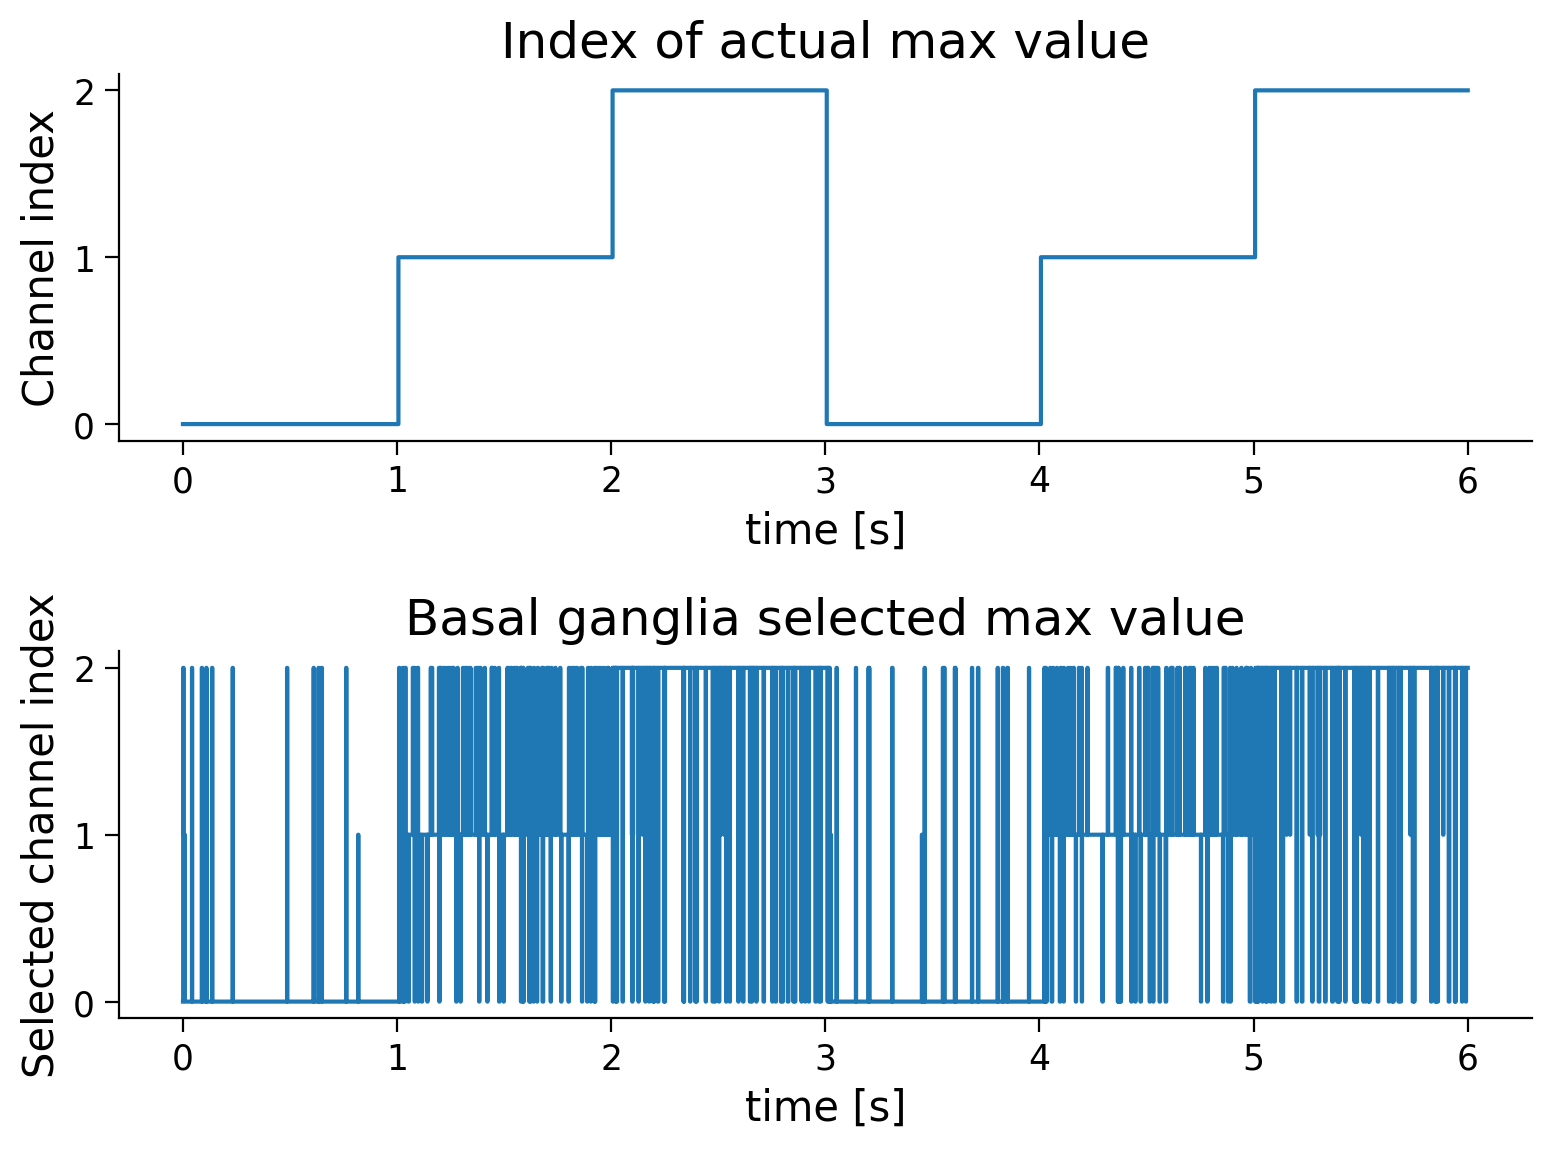

In [ ]:
plt.figure()

t = sim.trange()
actual_max = sim.data[input_actions].argmax(axis=1)
selected_max = sim.data[selected_action].argmax(axis=1)

plt.subplot(2, 1, 1)
plt.step(t, actual_max, where="post")
plt.ylim(-0.1, 2.1)
plt.yticks([0, 1, 2])
plt.xlabel("time [s]")
plt.ylabel("Channel index")
plt.title("Index of actual max value")

plt.subplot(2, 1, 2)
plt.step(t, selected_max, where="post")
plt.ylim(-0.1, 2.1)
plt.yticks([0, 1, 2])
plt.xlabel("time [s]")
plt.ylabel("Selected channel index")
plt.title("Basal ganglia selected max value")

plt.tight_layout()

In [ ]:
#@markdown #### To make the results easier to interpret, I compared actual_max, the channel with the largest input, with selected_max, the channel selected by the basal ganglia.

#@markdown #### correct = actual_max == selected_max

#@markdown #### The == checks whether the two values are equal. This creates correct, which contains True when the basal ganglia selected the correct channel and False when it did not. The mean is then used to calculate the percentage of correct selections.

#@markdown #### The selection accuracy was 91.25%.

correct = actual_max == selected_max
accuracy = correct.mean() * 100

print("Selection accuracy:", accuracy, "%")

Selection accuracy: 91.25 %


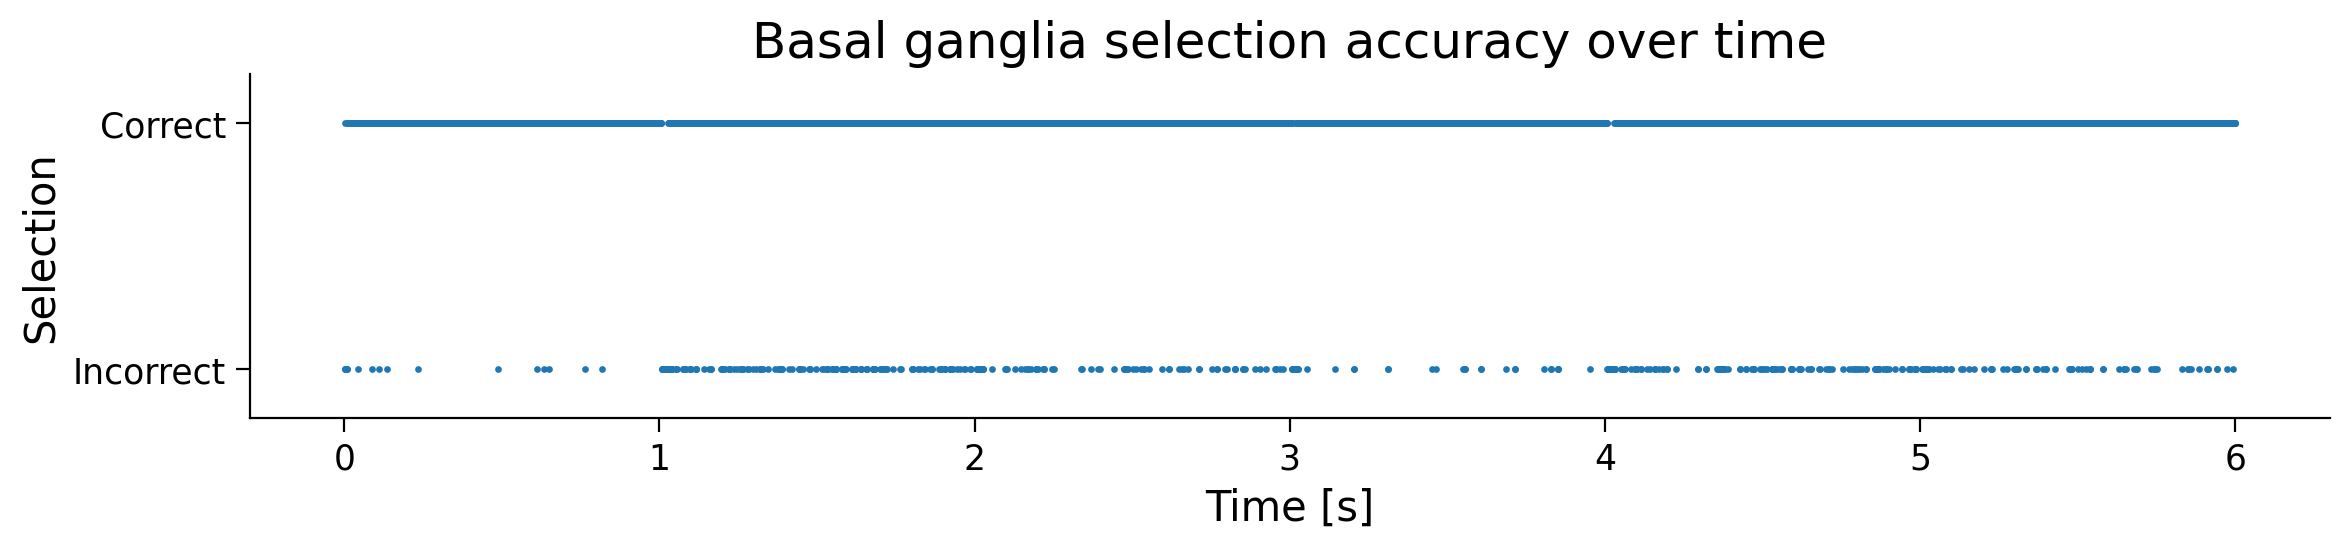

In [ ]:
#@markdown ####I also plotted correct and incorrect selections across time. This showed that most selections were correct, with brief incorrect selections scattered throughout the simulation. The earlier channel-index plot made the network appear much less accurate than it actually was.

#@markdown ####Reducing the dominant input from 0.8 to 0.3 made action selection less consistent, but the basal ganglia still selected the correct channel most of the time. This suggests that the network can distinguish between competing actions even when their input values are closer together, although weaker differences introduce more selection errors.

correct = actual_max == selected_max

plt.figure(figsize=(12, 3))
plt.scatter(t, correct, s=2)

plt.yticks([0, 1], ["Incorrect", "Correct"])
plt.xlabel("Time [s]")
plt.ylabel("Selection")
plt.title("Basal ganglia selection accuracy over time")
plt.ylim(-0.2, 1.2)

plt.tight_layout()